**Overview:** This is a customization of a Jupyter Notebook developed by Dr. Madhu Sridhar of NASA OSDI, for the extraction and compositing of [Harmonized Landsat Sentinel-2 (HLS)](https://www.earthdata.nasa.gov/data/projects/hls) data, the generation of vegetation indices from said data, and generation of mosaics. The original notebook can be found [here](https://github.com/NASA-IMPACT/hls-composite-bdec/blob/main/scripts/bdec_composite_mosaic_example.ipynb).

*Last updated: 04 May 2026*

In [1]:
# Install required packages
!pip install rioxarray
# !pip install datashader
!pip install pandas
!pip install geopandas
!pip install xarray
!pip install dask
!pip install hvplot
!pip install matplotlib
!pip install numpy
!pip install boto3
!pip install jupyter_bokeh

!pip install datetime
!pip install shapely
!pip install tqdm

!pip install rasterio

  Using cached jupyter_bokeh-4.0.5-py3-none-any.whl.metadata (7.1 kB)
Using cached jupyter_bokeh-4.0.5-py3-none-any.whl (148 kB)
  Using cached datetime-6.0-py3-none-any.whl.metadata (34 kB)
  Using cached zope_interface-8.5-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (47 kB)
Using cached datetime-6.0-py3-none-any.whl (52 kB)
Using cached zope_interface-8.5-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl (270 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [datetime]rface]


In [2]:
import os

import rioxarray
import pandas as pd
import geopandas as gpd
import xarray as xr
import hvplot.xarray
import dask
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
from rioxarray.merge import merge_datasets, merge_arrays
import shapely
from shapely.geometry import Polygon
import threading
from tqdm.notebook import tqdm

import rasterio

os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'

In [29]:
bucket_name = 'hls-composite-bdec'
tile_list =["37NCA", "37MBV", "37MCV", "37NBA"]
#tile_list =["37MCV"]
shapefile_path = r"../geojson/Kenya.geojson"

output_dir =  "../output"
year = "2025"

## Composite algorithm.
composite_alg = "median-monthly"
no_data_value = -9999

In [30]:
def get_list_of_files_from_s3(bucket_name, prefix):
    """
        function to get s3 file links from bucket and prefix
    """
    import boto3
    from botocore import UNSIGNED
    from botocore.client import Config

    s3 = boto3.resource('s3', config=Config(signature_version=UNSIGNED))
    bucket = s3.Bucket(bucket_name)

    files = []
    for obj in bucket.objects.filter(Prefix=prefix):
        files.append(f"s3://{bucket_name}/"+obj.key)
    return files

def gen_prefix(composite_alg="median-monthly", year="2020", tile="37NCA", granule_name=""):
    """
        construct prefix from variables
        UPDATE the prefix if needed
    """
    ## prefix for 'initial' results
    # return f'test-composite-{composite_alg}/{tile}/{year}/{granule_name}'

    ## Step-1 prototype results
    return  f'step-2-evaluation-prototype-data/composite-{composite_alg}/{tile}/{year}/{granule_name}'

## Process granules
s3_file_links = []
for tile in tile_list:
    prefix = gen_prefix(composite_alg=composite_alg, year=year, tile=tile)
    s3_file_links.extend(get_list_of_files_from_s3(bucket_name, prefix))

In [31]:
# print first few links in the list
s3_file_links[:10]

['s3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/37NCA/2025/HLS.M30.T37NCA.2025001.2025031.2.0/HLS.M30.T37NCA.2025001.2025031.2.0.Blue.std.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/37NCA/2025/HLS.M30.T37NCA.2025001.2025031.2.0/HLS.M30.T37NCA.2025001.2025031.2.0.Blue.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/37NCA/2025/HLS.M30.T37NCA.2025001.2025031.2.0/HLS.M30.T37NCA.2025001.2025031.2.0.DOY.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/37NCA/2025/HLS.M30.T37NCA.2025001.2025031.2.0/HLS.M30.T37NCA.2025001.2025031.2.0.Fmask.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/37NCA/2025/HLS.M30.T37NCA.2025001.2025031.2.0/HLS.M30.T37NCA.2025001.2025031.2.0.Green.std.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/37NCA/2025/HLS.M30.T37NCA.2

In [32]:
# subset links to separate bands
s3_file_links_red = [f for f in s3_file_links if 'Red.tif' in f]
s3_file_links_nir = [f for f in s3_file_links if 'NIR_Narrow.tif' in f]

In [33]:
composite_duration = [".".join(link.split(".")[3:5]) for link in s3_file_links_red if tile_list[0] in link]
composite_duration

['2025001.2025031',
 '2025032.2025059',
 '2025060.2025090',
 '2025091.2025120',
 '2025121.2025151',
 '2025152.2025181',
 '2025182.2025212',
 '2025213.2025243',
 '2025244.2025273',
 '2025274.2025304',
 '2025305.2025334',
 '2025335.2025365']

In [34]:
len(s3_file_links_red)

48

In [35]:
# get links for first composite duration
s3_file_links_red_duration0 = [f for f in s3_file_links_red if composite_duration[0] in f]

In [36]:
def read_rasters(raster_paths, target_crs):
    for path in raster_paths:
        # Load with chunks to keep memory usage low (Dask)
        da = rioxarray.open_rasterio(path, lock=False, chunks={'x': 3660, 'y': 3660}, mask_and_scale=True)

        # 2. Reproject if the CRS doesn't match the target
        if da.rio.crs != target_crs:
            # 'reproject' calculates the new coordinates and transforms
            da = da.rio.reproject(target_crs)

        processed_arrays.append(da)
    return processed_arrays

def plot_shapefile_and_tiles(gdf1, gdf2):
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(5,5)
    gdf2.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            alpha=0.5)

    gdf1.plot(
            ax=ax,
            facecolor='blue',
            alpha=0.5)
#         ax.set_axis_off()
    plt.show()

def mosaic_reproject_clip(raster_links, shapefile_path, output_crs=None, nodata=-9999, clip=False, plot=False):
    """
    raster_paths: GeoTIFFS S3 links
    shapefile_path: Loads a shapefile of the study area

    This function
    1. Loads a shapefile.
    2. Reprojects all rasters to a common CRS.
    3. Mosaics them into one xarray.
    4. Clips to the shapefile boundary.

    """
    # 1. Load the shapefile to define the study area
    gdf = gpd.read_file(shapefile_path)

    # If no output_crs is provided, use the shapefile's CRS as the "Master"
    if output_crs is None:
        target_crs = gdf.crs
    else:
        target_crs = output_crs

    processed_arrays = []
    processed_arrays = read_rasters(raster_links, target_crs)

    #  Merge (Mosaic) the aligned rasters
    # All rasters MUST have the same CRS for merge_arrays to work
    merged = merge_arrays(processed_arrays)

    #print("Done merging rasters")
    if clip:
        # Clip to the shapefile
        # Ensure shapefile matches the target_crs (just in case)
        if gdf.crs != target_crs:
            gdf = gdf.to_crs(target_crs)

        # Apply the clip
        clipped = merged.rio.clip(
            gdf.geometry.apply(lambda g: g.__geo_interface__),
            crs=target_crs,
            drop=True
        )
        # Set the nodata value properly in the metadata
        clipped = clipped.rio.write_nodata(nodata, encoded=True)
        #print("Done clipping rasters to shapefile")

        return clipped
    else:
        return merged

In [37]:
# 1. Define your bounding box (minx, miny, maxx, maxy)
bbox = (36.874685390053116, -0.5053306872360258, 37.871694667396866, 0.11813679867827266)

# 2. Convert to a Shapely Polygon
poly = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]),
                (bbox[2], bbox[3]), (bbox[0], bbox[3])])

# 3. Create GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")

print(gdf)

                                            geometry
0  POLYGON ((36.87469 -0.50533, 37.87169 -0.50533...


In [38]:
target_crs = gdf.crs

#print(f"Aligning {len(raster_paths)} rasters to CRS: {target_crs}")
processed_arrays = []
processed_arrays = read_rasters(s3_file_links_red_duration0, target_crs)
#print("Done loading rasters")

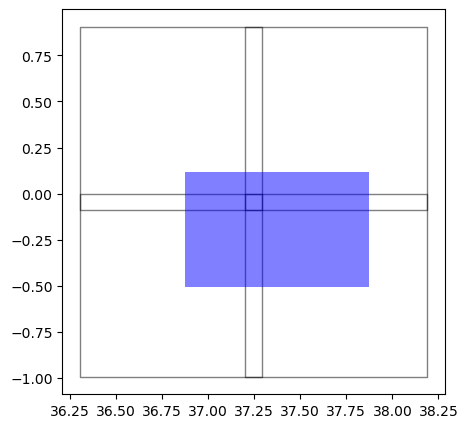

In [39]:
## Plot shape file and tile boundaries
bboxes = []
for ds in processed_arrays:
        bounds = ds.rio.bounds()
        bbox = shapely.box(*bounds)  # Create a shapely box object
        bboxes.append(bbox)

gdf2 = gpd.GeoDataFrame(geometry=bboxes, crs=processed_arrays[0].rio.crs)
plot_shapefile_and_tiles(gdf, gdf2)

In [40]:
# Convert the GeoPandas Data Frame (GDF)
geojson_object = gdf.to_json()

In [41]:
## Mosaic example
## Loop through composites, merge and save ndvi rasters
for i in tqdm(range(len(composite_duration))):
    duration = composite_duration[i]

    print(f"Processing {duration}")
    s3_file_links_red_duration = [f for f in s3_file_links_red if duration in f]
    s3_file_links_nir_duration = [f for f in s3_file_links_nir if duration in f]

    # Mosaic and clip
    mosaic_da_red = mosaic_reproject_clip(s3_file_links_red_duration, geojson_object, nodata=-9999, clip=True, plot=False)
    mosaic_da_nir = mosaic_reproject_clip(s3_file_links_nir_duration, geojson_object, nodata=-9999, clip=True, plot=False)

    # calculate NDVI from red and nir bands
    mosaic_ndvi = (mosaic_da_nir - mosaic_da_red)/(mosaic_da_nir + mosaic_da_red)
    mosaic_ndvi.name = "NDVI"

    # write mosaic ndvi
    #mosaic_ndvi.rio.to_raster(f"{output_dir}/mosaic_ndvi_{duration}.tif", tiled=True, lock=threading.Lock())
    mosaic_ndvi.rio.to_raster(f"mosaic_ndvi_{duration}.tif", tiled=True, lock=threading.Lock())

print(f"Done Mosaicing")


  0%|          | 0/12 [00:00<?, ?it/s]

Processing 2025001.2025031
Processing 2025032.2025059
Processing 2025060.2025090
Processing 2025091.2025120
Processing 2025121.2025151
Processing 2025152.2025181
Processing 2025182.2025212
Processing 2025213.2025243
Processing 2025244.2025273
Processing 2025274.2025304
Processing 2025305.2025334
Processing 2025335.2025365
Done Mosaicing
